# K-Means — Customer Segmentation (Realistic Generator + PCA visualization)

Unsupervised learning workflow: scaling, choosing k, cluster profiling, and visualization.

**Author:** Olivier Robert-Duboille

**What you'll practice**
- reproducible data loading
- EDA with clear plots
- feature engineering / preprocessing pipelines
- cross-validation + hyperparameter tuning
- baseline vs advanced model comparison

This notebook is part of the *advanced-ml-mastery-collection* and is designed to be reproducible and portfolio-ready.

In [1]:
# Reproducibility
import os
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plot settings
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_context('talk')


## Generate a customer dataset

Simulate customer behaviour with latent segments so clustering has real structure.

In [2]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(SEED)
n = 5000

# Latent segments
segment = rng.choice([0,1,2,3], size=n, p=[0.25,0.35,0.25,0.15])
base_income = np.select(
    [segment==0, segment==1, segment==2, segment==3],
    [rng.normal(35000, 8000, n), rng.normal(52000, 12000, n), rng.normal(80000, 18000, n), rng.normal(110000, 25000, n)]
)
spend = np.select(
    [segment==0, segment==1, segment==2, segment==3],
    [rng.normal(1200, 400, n), rng.normal(2600, 800, n), rng.normal(4200, 1200, n), rng.normal(5200, 1400, n)]
)
visits = np.select(
    [segment==0, segment==1, segment==2, segment==3],
    [rng.poisson(4, n), rng.poisson(7, n), rng.poisson(9, n), rng.poisson(6, n)]
)
recency = np.select(
    [segment==0, segment==1, segment==2, segment==3],
    [rng.gamma(3, 10, n), rng.gamma(2.2, 8, n), rng.gamma(1.8, 7, n), rng.gamma(2.5, 6, n)]
)

df = pd.DataFrame({
    'income': np.clip(base_income, 15000, None),
    'annual_spend': np.clip(spend, 100, None),
    'visits_per_month': visits,
    'recency_days': recency,
})
display(df.head())


,income,annual_spend,visits_per_month,recency_days
0,63207.972864,4860.905303,8,20.794733
1,76693.626815,705.790104,10,17.071680
2,89028.480395,7901.089445,6,11.096453
3,94758.033884,4802.784444,9,16.479583
4,32773.068478,1327.325963,8,84.950299


## EDA

Explore distributions, relationships, and potential issues (missing values, skew, outliers).

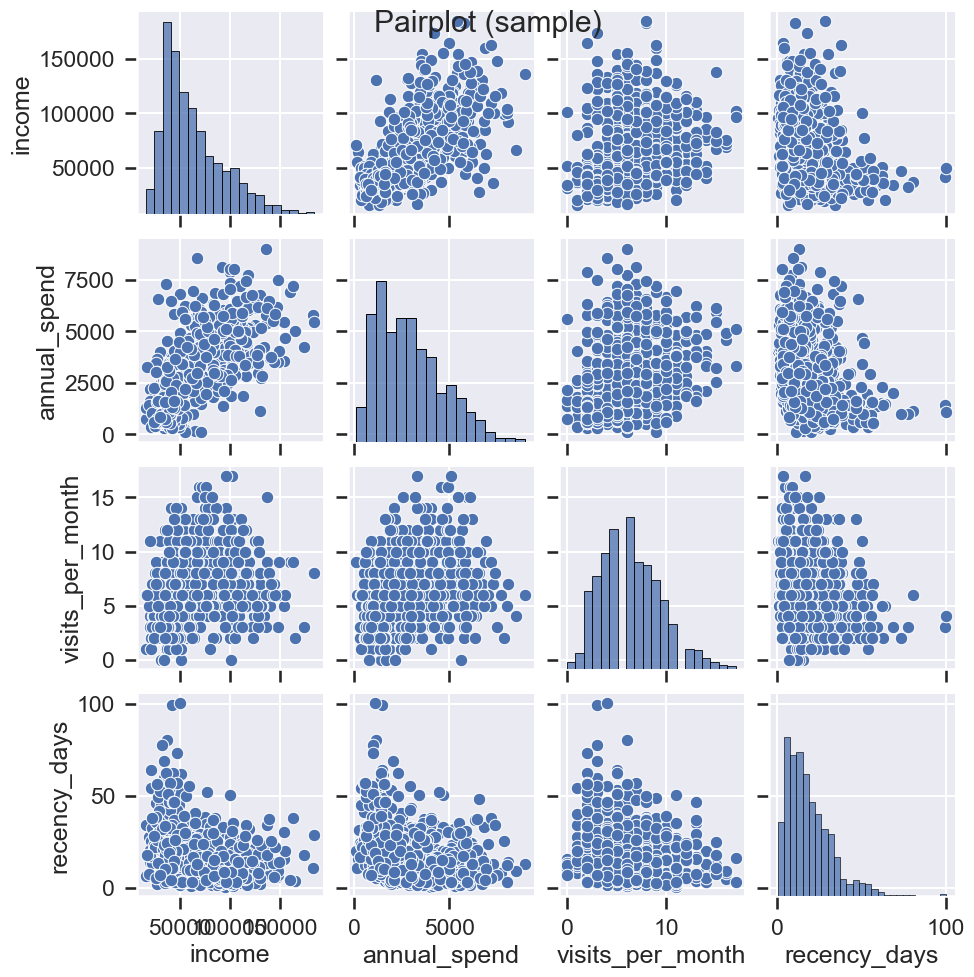

In [3]:
sns.pairplot(df.sample(800, random_state=SEED))
plt.suptitle('Pairplot (sample)')
plt.show()


## Choose k (elbow + silhouette)

Select the number of clusters using complementary criteria.

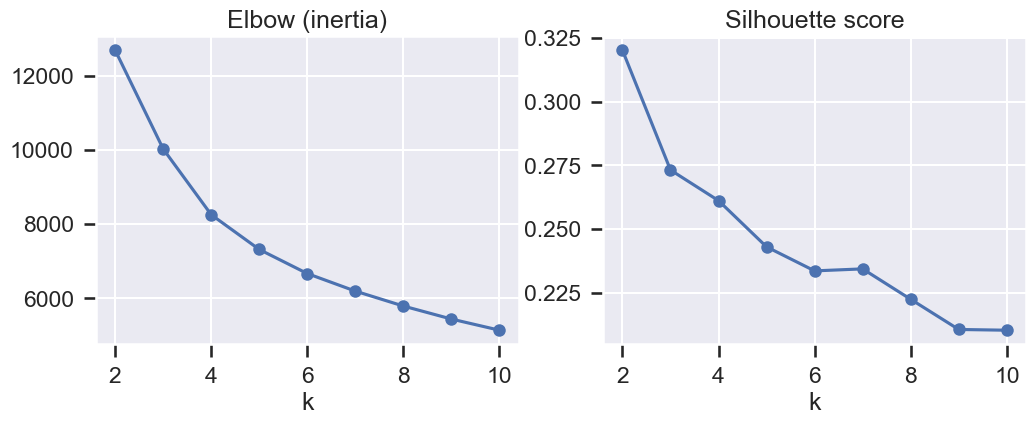

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = df.values
Xs = StandardScaler().fit_transform(X)

ks = range(2, 11)
inertias = []
sil = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(Xs)
    inertias.append(km.inertia_)
    sil.append(silhouette_score(Xs, labels))

fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(list(ks), inertias, marker='o')
ax[0].set_title('Elbow (inertia)')
ax[0].set_xlabel('k')
ax[1].plot(list(ks), sil, marker='o')
ax[1].set_title('Silhouette score')
ax[1].set_xlabel('k')
plt.show()


## Fit final model + cluster profiling

Summarize cluster characteristics to translate clusters into business personas.

,income,annual_spend,visits_per_month,recency_days
cluster,,,,
0,45097.502977,2052.552358,4.848328,15.567733
1,38167.043034,1479.028815,4.488491,42.395806
2,106446.042334,5201.056448,6.124272,13.698177
3,67631.826518,3405.151476,10.031637,13.512878


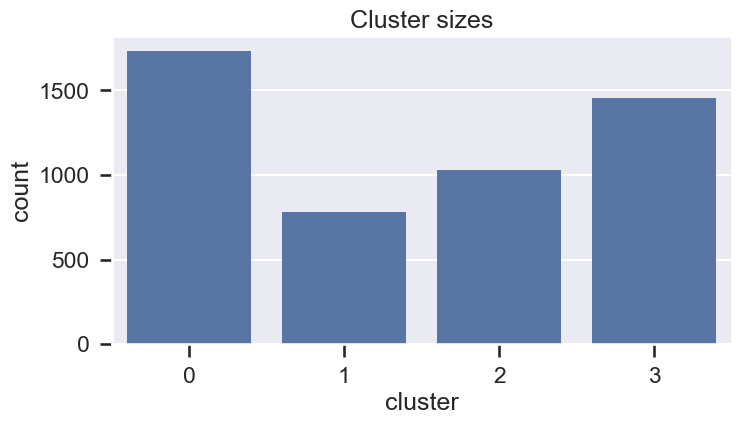

In [5]:
k = 4
km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
labels = km.fit_predict(Xs)
df_out = df.copy()
df_out['cluster'] = labels

display(df_out.groupby('cluster').mean(numeric_only=True))

plt.figure(figsize=(8,4))
sns.countplot(x='cluster', data=df_out)
plt.title('Cluster sizes')
plt.show()


## Visualize clusters with PCA

Project to 2D for interpretability while remembering projection distortions.

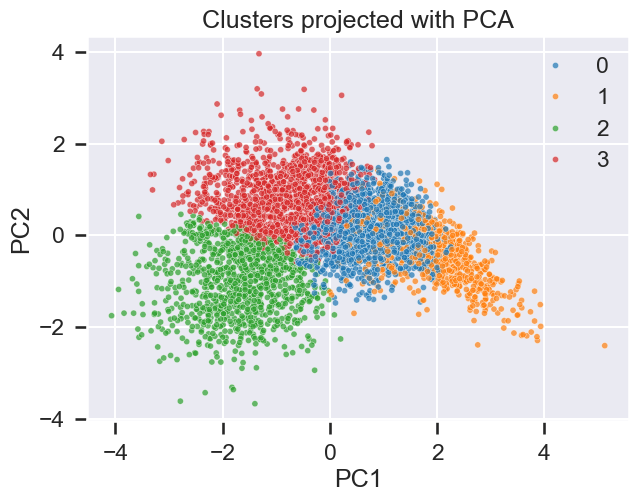

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=SEED)
Z = pca.fit_transform(Xs)

plt.figure(figsize=(7,5))
sns.scatterplot(x=Z[:,0], y=Z[:,1], hue=labels, palette='tab10', s=20, alpha=0.7)
plt.title('Clusters projected with PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()
